# ***PA - Part III: Training a Robust Model - Optional/Bonus*** (10pt)

**Keywords**: Adversarial Robustness Training

**About the dataset**: \
The [MNIST](https://en.wikipedia.org/wiki/MNIST_database) database (Modified National Institute of Standards and Technology database) is a large database of handwritten digits that is commonly used for training various image processing systems.\
The MNIST database contains 70,000 labeled images. Each datapoint is a $28\times 28$ pixels grayscale image.

**Agenda**:
* The PA is split into three parts, the first part dealing with miniature models which we will build from scratch, the second part dealing with modern architectures and the bonus third part dealing with training vision models robust to adversarial attacks.
* In this part, you will train a 2-hidden layer neural network which is robust to adversarial attacks.
* You will train models on adversarial examples generated using FGSM and PGD.

**Note:**
* Hardware acceleration (GPU) is recommended but not required for this part.
* A note on working with GPU:
  * Take care that whenever declaring new tensors, set `device=device` in parameters.
  * You can also move a declared torch tensor/model to device using `.to(device)`.
  * To move a torch model/tensor to cpu, use `.to('cpu')`
  * Keep in mind that all the tensors/model involved in a computation have to be on the same device (CPU/GPU).
* Run all the cells in order.
* Only **add your code** to cells marked with "TODO:" or with "..."
* You should not have to change variable names where provided, but you are free to if required for your implementation.

### ***Setup: Imports and Utils***

In [1]:
# install this library
!pip install gdown


   -------------------- ------------------- 1/2 [gdown]
   ---------------------------------------- 2/2 [gdown]




[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# imports
import torch
import torch.nn as nn
import numpy as np
import requests
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import gdown
from zipfile import ZipFile

# set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

# loading the dataset full MNIST dataset
mnist_train = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())

mnist_train.data = mnist_train.data.to(device)
mnist_test.data = mnist_test.data.to(device)

mnist_train.targets = mnist_train.targets.to(device)
mnist_test.targets = mnist_test.targets.to(device)

# reshape and min-max scale
X_train =  (mnist_train.data.reshape((mnist_train.data.shape[0], -1))/255).to(device)
y_train = mnist_train.targets
X_test = (mnist_test.data.reshape((mnist_test.data.shape[0], -1))/255).to(device)
y_test = mnist_test.targets

# first few examples
example_data = mnist_test.data[:18]/255
example_data_flattened  = example_data.view((example_data.shape[0], -1)).to(device) # needed for training
example_labels = mnist_test.targets[:18].to(device)

cuda:0




---



---




### **Adversarial training:**
* To train robust models, the most intuitive strategy is to train on adversarial examples.
* The adversarial (robust) loss function is defined as:
$\underset{\theta}{\min} \frac{1}{|S|}\sum_{x,y\in S} \underset{∥δ∥≤ϵ}{\max}\,ℓ(h_θ(x+δ),y)$, \
where $\theta$ are the learnable parameters, $S$ is the set of training examples with $x$ representing the input example and $y$ the ground truth label, $h_\theta$ is the score function (neural network model), $\delta$ is the attack perturbation, and $\epsilon$ is the attack budget.

* This is also known as the min-max loss function. The gradient descent step now becomes:\
$\theta:=\theta-\frac{\alpha}{|B|}\sum_{x,y\in B} ∇_θ \underset{∥δ∥≤ϵ}{\max}\,ℓ(h_θ(x+δ),y)$,\
where $B$ is the mini-batch and $\alpha$ is the learning rate.

* Now the question becomes how to solve the inner term: $∇_θ \underset{∥δ∥≤ϵ}{\max}\,ℓ(h_θ(x+δ),y)$ of the gradient descent step.
* For this, we can use **Danskin’s Theorem**, which states that to compute the (sub)gradient of a function containing a max term, we need to simply
  1. find the maximum and,
  2. compute the normal gradient evaluated at this point.
* This holds only when you have the exact maximum.  Note that it is not possible to solve the inner maximization problem exactly (NP-hard). However, the better job we do of solving the inner maximization problem, the closer it seems that Danskin’s theorem starts to hold. That is why we can re-use methods such as FGSM/PGD to find approximate worst case examples.
* In other words, we can perform the attack to find $δ^{*} = \underset{∥δ∥≤ϵ}{\arg\max}ℓ(h_θ(x+δ),y)$, and then compute this term at the perturbed image: $∇_θℓ(h_θ(x+δ^{*}),y)$.

In summary, we will create an adversarial example for each datapoint in the mini-batch and use the loss corresponding to these adversarial examples to compute the gradient.  

We explore two attacks to get the perturbration - Fast Gradient Sign Method (FGSM) and Projected Gradient Descent (PGD)

* In the Fast Gradient Sign Method (FGSM), the perturbation $\delta$ on an input example (e.g. input image) $X$ is given by $\epsilon\cdot \text{sign}(g)$.
  * Here, $g$ is the gradient of the loss function $g:=\nabla_\delta \ell(h_\theta (x+\delta),y)$.
  * $\ell$ is the loss function, more precisely `nn.CrossEntropyLoss`. In the first timestep, this value of $\delta$ is $0$.

* For the Projected Gradient Descent (PGD) attack, you will create an adversarial example by iteratively performing **steepest descent** with a fixed step size $\alpha$.
  * The update rule is: $\delta:=P(\delta+\alpha\,\text{sign}(\nabla_\delta \ell(h_\theta(x+\delta),y)))$.
  * Here $\delta$ is the perturbation, $\theta$ are the frozen DNN parameters, $x$ and $y$ is the training example and its ground truth label respectively.
  * $h_\theta$ is the score function and $\ell$ denotes the loss function.
  * $P$ denotes the projection onto a norm ball ($l_\infty, l_1, l_2$, etc.) of interest. For $l_\infty$ ball, this just means clamping the value of $\delta$ between $-\epsilon$ and $\epsilon$.





---



### *(a) Setup* (4pt)

* In this part you will create a few adversarial examples using FGSM and PGD attacks. Use an attack budget $\epsilon=0.05$.


#### #1. Define the `fgsm` function

* Define a function `fgsm` which takes as input the neural network model (`model`), test examples (`X`), target labels (`y`), and the attack budget (`epsilon`).
* Return the value of the perturbation ($\delta$) after one gradient descent step.

In [4]:
#######
#TODO:

import torch
import torch.nn as nn

def fgsm(model, x, y, epsilon):
    delta = torch.zeros_like(x, requires_grad=True)

    output = model(x + delta)
    loss = nn.CrossEntropyLoss()(output, y)
    loss.backward()
    return epsilon * delta.grad.detach().sign()
#######


#### #2. Define the `pgd` function

* Instead of using FGSM, now use Projected Gradient Descent (PGD) with projection on $l_\infty$ ball for the attack.
* Define a function `pgd` that takes as input the neural network model (`model`), training examples (`X`), target labels (`y`), step size (`alpha`), attack budget (`epsilon`), and number of iterations (`num_iter`).
* Return the perturbation ($\delta$) after `num_iter` gradient descent steps.

In [5]:
#TODO:

def pgd(model, x, y, alpha, epsilon, num_iter):
    # random sampling uniformly between 0 and 1
    delta = torch.rand_like(x)
    # bring delta in -eps to eps range
    # how? --> [0, 1] --> [0, 2*eps] --> [-eps, eps]
    delta = delta * 2 * epsilon - epsilon
    delta = delta.detach()

    for t in (range(num_iter)):
        delta.requires_grad = True

        model.zero_grad()
        output = model(x + delta)
        loss = nn.CrossEntropyLoss()(output, y)
        loss.backward()

        grad = delta.grad.detach()
        delta = delta + alpha * grad.sign()
        delta = torch.clamp(delta, -epsilon, epsilon)
        delta = torch.clamp(x + delta, 0, 1) - x
        delta = delta.detach()

    return delta

#### #3. Define a 2 hidden-layer NN in PyTorch

* Create a 2-hidden-layer neural network model in PyTorch.
* The input should be the size of the flattened MNIST image, and output layer should be of size 10, which is the number of target labels.
* Each of the two hidden layers should be of size 1024 with ReLU activations between each subsequent layer except the last layer.

You can refer to the structure of `NN_Model` from Part 1 (d) #5

In [6]:
#######
from torch.nn.functional import relu
#TODO:
class NN_Model(nn.Module):
    def __init__(self):
        super(NN_Model, self).__init__()
        
        self.fc1 = nn.Linear(28*28, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)

    def forward(self, X):
        X = X.view(X.shape[0], -1)
        X = relu(self.fc1(X))
        X = relu(self.fc2(X))
        X = self.fc3(X)
        return X

#######

#### #4. Adversarial Training Framework

* Define a function `train_torch_model_adversarial`
  * which takes as input: a PyTorch model (`model`), batch size (`batch_size`), loss function (`criterion`), maximum number of epochs (`max_epochs`), training data (`X_train, y_train`), learning rate (`lr`), tolerance for stopping (`tolerance`), adversarial strategy (`adversarial_strategy`: `None/'fgsm'/'pgd'`), and attack budget(`epsilon`).
  * Note: use an SGD optimizer with the given learning rate (`lr`) to update all the model parameters.
* If `adversarial_strategy` is `None`, don't train on adversarial examples.
* This function will return a tuple of `(model, losses)`, where `model` is the trained model, and `losses` are a list of tuple of loss logged every epoch.
* The only difference from the function `train_torch_model` that you wrote in Part 1 (c) #2 is that you find the adversarial noise using an attack (based on `adversarial strategy`) and add it to the input before training with it.

In [10]:
#######
#TODO:
def train_torch_model_adversarial(model, batch_size, criterion, max_epochs, \
                                  X_train, y_train, lr, tolerance, \
                                  adversarial_strategy, epsilon):
    losses = []
    num_batches = X_train.shape[0] // batch_size
    prev_loss = float('inf')
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    for epoch in tqdm(range(max_epochs)):
        model.train()
        epoch_loss = 0.0

        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            x_batch = X_train[start_idx:end_idx].to(device)
            y_batch = y_train[start_idx:end_idx].to(device)

            if adversarial_strategy == 'fgsm':
                delta = fgsm(model, x_batch, y_batch, epsilon)
            elif adversarial_strategy == 'pgd':
                # hard coded for next part
                delta = pgd(model, x_batch, y_batch, alpha=0.01, epsilon=epsilon, num_iter=40)
            else:
                delta = torch.zeros_like(x_batch)

            optimizer.zero_grad()
            outputs = model(x_batch + delta)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= num_batches
        losses.append((epoch, epoch_loss))

        if abs(prev_loss - epoch_loss) < tolerance:
            print(f"Early stopping at epoch {epoch+1} with loss: {epoch_loss:.4f}")
            break
        prev_loss = epoch_loss
    return model, losses

#######



---



### *(b) Training and evaluation with different strategies (3 points)*

####  #1. Standard, FGSM-based, and PGD-based training

* Train three models:
  * without adversarial training,
  * with adversarial training using `fgsm`
  * with adversarial training using `pgd`.
* Hyperparameters
  * Use attack budget `epsilon` of 0.05.
  * Use a batch-size 512
  * Train for 20 epochs with learning rate $10^{-2}$, and early stopping tolerance of $10^{-6}$.
  * For `pgd`, use a step-size `alpha=0.01` and number of iterations `num_iter=40` when training.

  Note: PGD implementation will be slow (1hr+) when using a non-GPU runtime.

In [11]:
#######
#TODO:
trained_models = {}
batch_size=512
tolerance = 1e-6
lr = 0.01
max_epochs = 20
epsilon = 0.05

train_with_clean = False

model = NN_Model().to(device)
criterion = nn.CrossEntropyLoss()
model, losses = train_torch_model_adversarial(
    model, batch_size, criterion, max_epochs, \
    X_train, y_train, lr, tolerance, \
    adversarial_strategy='None', epsilon=epsilon
)
trained_models['None']=(model, losses)
print('Final training loss for None model:', losses[-1][1])

model = NN_Model().to(device)
criterion = nn.CrossEntropyLoss()
model, losses = train_torch_model_adversarial(
    model, batch_size, criterion, max_epochs, \
    X_train, y_train, lr, tolerance, \
    adversarial_strategy='fgsm', epsilon=epsilon
)
trained_models['fgsm']=(model, losses)
print('Final training loss for fgsm model:', losses[-1][1])

model = NN_Model().to(device)
criterion = nn.CrossEntropyLoss()
model, losses = train_torch_model_adversarial(
    model, batch_size, criterion, max_epochs, \
    X_train, y_train, lr, tolerance, \
    adversarial_strategy='pgd', epsilon=epsilon
)
trained_models['pgd']=(model, losses)
print('Final training loss for pgd model:', losses[-1][1])

#######

  0%|          | 0/20 [00:00<?, ?it/s]

Final training loss for None model: 0.3547703732027967


  0%|          | 0/20 [00:00<?, ?it/s]

Final training loss for fgsm model: 0.8776726498563066


  0%|          | 0/20 [00:00<?, ?it/s]

Final training loss for pgd model: 0.7060453815337939


#### #2. Measuring Standard Performance
* Compute and print the accuracy of each of the three trained models on the clean test dataset.
* You can implement a function similar to the `print_accuracies_torch` function from HW1-Q1 (but compute accuracy only for the test set).

In [12]:
#######
#TODO:

from sklearn.metrics import accuracy_score
import numpy as np

def get_accuracies_torch(model, X, y):
    model.eval()

    with torch.no_grad():
        preds = model(X)
        y_pred = torch.argmax(preds, dim=1).cpu().numpy()
    return accuracy_score(y.cpu().numpy(), y_pred)


for key in trained_models:
    model, _ = trained_models[key]
    acc = get_accuracies_torch(model, X_test, y_test)
    print('Accuracy of {} model on clean test dataset: {}'.format(key, acc))

#######

Accuracy of None model on clean test dataset: 0.9052
Accuracy of fgsm model on clean test dataset: 0.889
Accuracy of pgd model on clean test dataset: 0.8962


#### #3. Measuring Adversarial Robustness

* Using the same test dataset, perform adversarial attack to compute robust accuracy for each of the three models. Report the robust accuracy of each of the three models for both:
  * FGSM attack
  * PGD attack
* Note: In total, you need to report 6 robust accuracies here (3 models * 2 attacks).
* To create PGD attack examples, use `alpha=0.01`, `num_iter=40`.

In [13]:
#######
#TODO:
for key in trained_models:
    model, _ = trained_models[key]

    # for fgsm
    delta = fgsm(model, X_test, y_test, epsilon)
    score = get_accuracies_torch(model, X_test + delta, y_test)
    print('Robust accuracy of {} model on fgsm attack: {}'.format(key, score))

    # for pgd
    delta = pgd(model, X_test, y_test, alpha=0.01, epsilon=epsilon, num_iter=40)
    score = get_accuracies_torch(model, X_test + delta, y_test)
    print('Robust accuracy of {} model on pgd attack: {}'.format(key, score))

#######

Robust accuracy of None model on fgsm attack: 0.5742
Robust accuracy of None model on pgd attack: 0.723
Robust accuracy of fgsm model on fgsm attack: 0.7237
Robust accuracy of fgsm model on pgd attack: 0.7845
Robust accuracy of pgd model on fgsm attack: 0.7126
Robust accuracy of pgd model on pgd attack: 0.7857


### *(c) Evaluate the robust trained models at different epsilon (1.5 points)*

* Report the robust accuracy of each of the three models (standard-trained, FGSM-trained and PGD-trained from **(b)**) using FGSM and PGD attacks at `epsilon = [0, 0.01, 0.02, ..., 0.09, 0.1]`.
* Plot a (single) graph of robust accuracy vs. `epsilon` (i.e. six curves, since we have 3 models and 2 attacks).

In [14]:
#######
# TODO:

eps_list = np.arange(0, 0.11, 0.01)

std_model_fgsm = list()
std_model_pgd = list()
fgsm_model_fgsm = list()
fgsm_model_pgd = list()
pgd_model_fgsm = list()
pgd_model_pgd = list()

for eps in eps_list:
    for key in trained_models:
        model, _ = trained_models[key]
        model.eval()

        delta = fgsm(model, X_test, y_test, eps)
        X_adv = torch.clamp(X_test + delta, 0, 1)
        fgsm_score = get_accuracies_torch(model, X_adv, y_test)

        delta = pgd(model, X_test, y_test, alpha=0.01, epsilon=eps, num_iter=40)
        X_adv = torch.clamp(X_test + delta, 0, 1)
        pgd_score = get_accuracies_torch(model, X_adv, y_test)

        if key == "None":
            std_model_fgsm.append(fgsm_score)
            std_model_pgd.append(pgd_score)
        elif key == "fgsm":
            fgsm_model_fgsm.append(fgsm_score)
            fgsm_model_pgd.append(pgd_score)
        elif key == "pgd":
            pgd_model_fgsm.append(fgsm_score)
            pgd_model_pgd.append(pgd_score)

#######

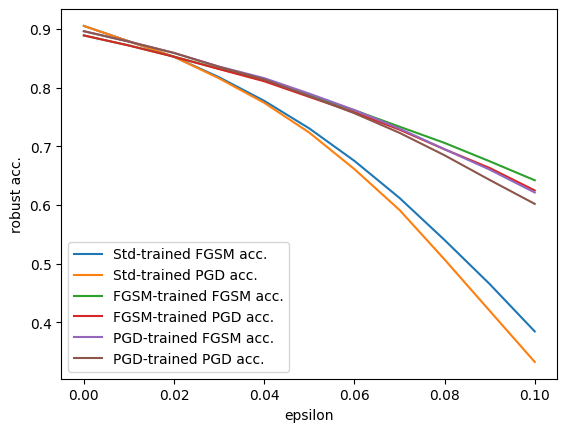

In [15]:
plt.plot(eps_list, std_model_fgsm, label='Std-trained FGSM acc.')
plt.plot(eps_list, std_model_pgd, label='Std-trained PGD acc.')

plt.plot(eps_list, fgsm_model_fgsm, label='FGSM-trained FGSM acc.')
plt.plot(eps_list, fgsm_model_pgd, label='FGSM-trained PGD acc.')

plt.plot(eps_list, pgd_model_fgsm, label='PGD-trained FGSM acc.')
plt.plot(eps_list, pgd_model_pgd, label='PGD-trained PGD acc.')

plt.xlabel('epsilon')
plt.ylabel('robust acc.')
plt.legend()
plt.show()

### *(d) Analysis of results (1.5 points)*

Describe and analyze the observations from the graph that you plotted in the previous question **(c)**.

As expected, all six accuracies decrease as the epsilon increases. We can also 
see that adversarial training in general significantly improves model performance
compared to standard training, as the standard models dropped to around 35% accuracy
at high epsilon, whereas the adversarial trained models hovered around 65%. PGD 
attacked models also have slightly lower accuracy, showing that PGD is the stronger 
attack vector compared to FGSM. 




---



---

